The mouse embryo Stereo-seq data: [gene expression data](https://db.cngb.org/stomics/mosta), [FASTQ files](https://db.cngb.org/search/project/CNP0001543).

The h5ad files of unspliced and spliced counts was processed from the FASTQ files by [SAW](https://github.com/STOmics/SAW).

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import seaborn as sns
import matplotlib.pyplot as plt
import STAVelo as stv
stv.settings.verbosity = 3
stv.settings.presenter_view = True
stv.set_figure_params("scvelo")
import warnings
warnings.filterwarnings("ignore")

# Read data

In [2]:
adata=sc.read("../data/T4_Mouse_Embryo_Stereoseq_E12.5/adata_us_bin50_anno_v2.h5ad")
for key in adata.obsm.keys():
    adata.obsm[key] = adata.obsm[key].astype(np.float64)

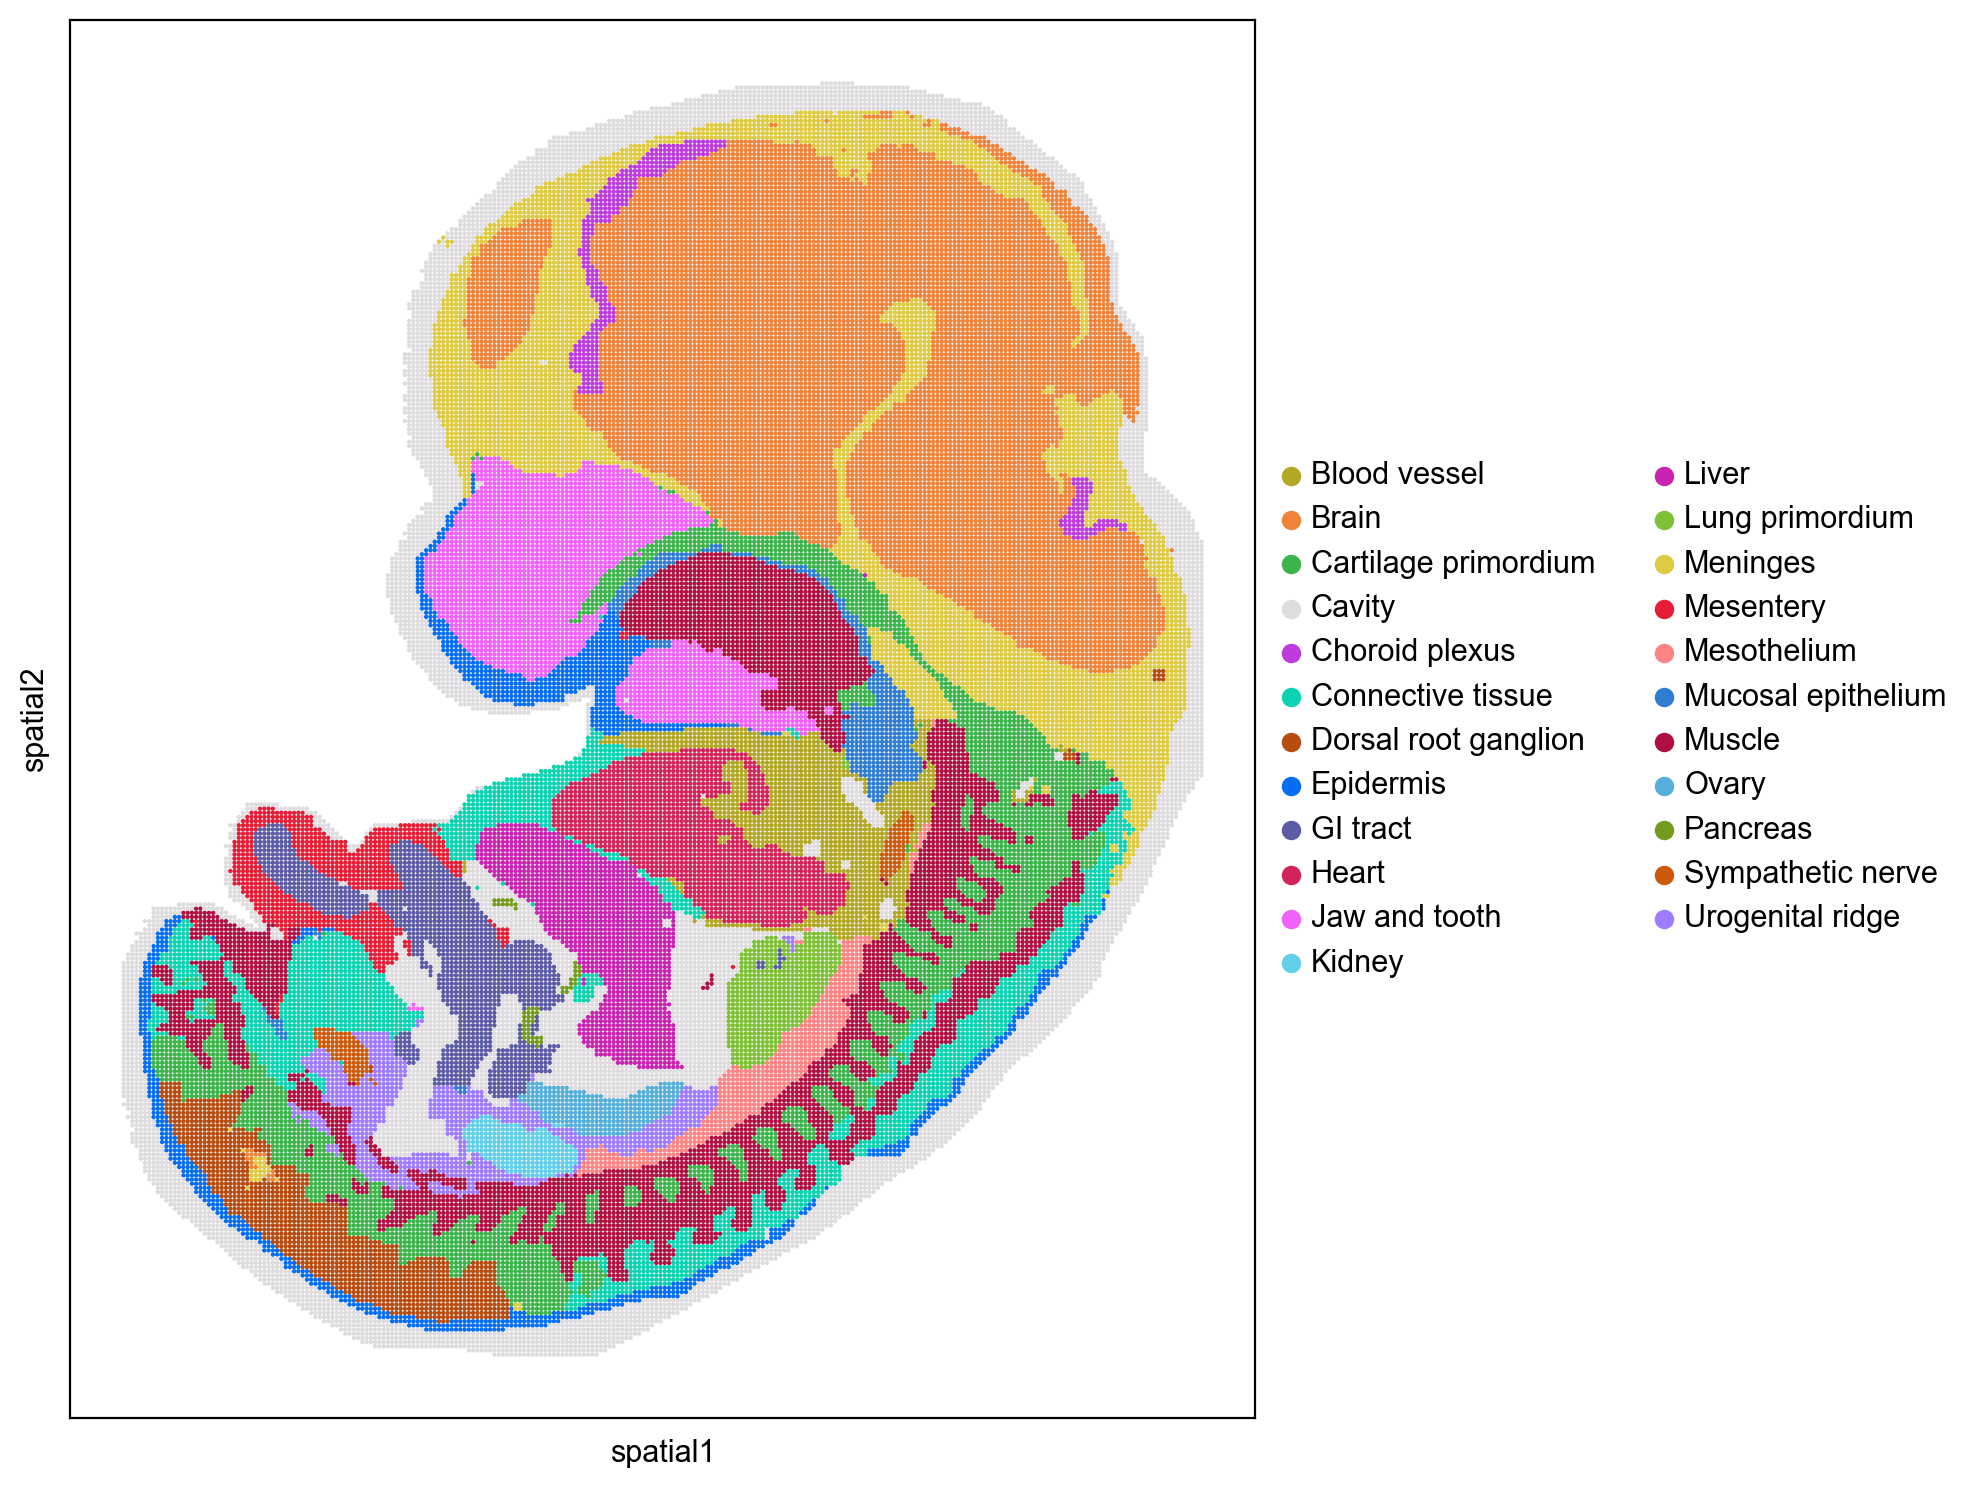

In [3]:
plt.rcParams["figure.figsize"] = (7.6, 9.2)
sc.pl.embedding(adata, basis="spatial", color="annotation", title="", s=10)

# Run model

In [4]:
stv.show_proportions(adata)
adata

Abundance of ['unspliced', 'spliced', 'ambiguous']: [0.09 0.91 0.  ]


AnnData object with n_obs × n_vars = 51913 × 40472
    obs: 'x', 'y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'annotation', 'development'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'annotation_colors'
    obsm: 'spatial'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [5]:
stv.filter_and_normalize(adata, min_shared_counts=1, n_top_genes=1000)
stv.moments(adata, n_pcs=30, n_neighbors=30)

Filtered out 25635 genes that are detected 1 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 1000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:34) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [6]:
stv.Cal_Spatial_Net(adata, rad_cutoff=80)

------Calculating spatial graph...
The graph contains 412094 edges, 51913 cells.
7.9382 neighbors per cell on average.


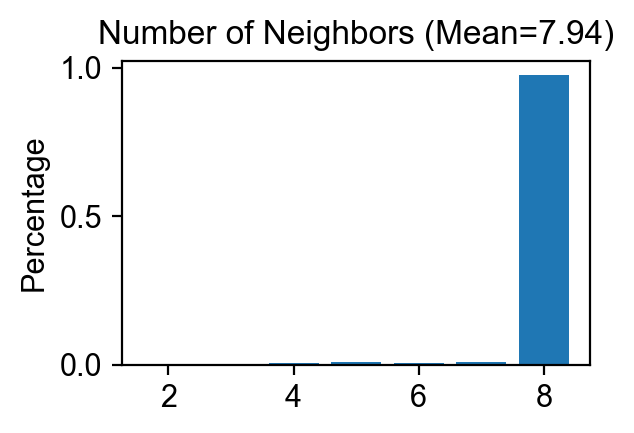

In [7]:
stv.Stats_Spatial_Net(adata)

In [8]:
adata = stv.train_STAVelo(adata, loss_type="cosine", w1 = 1, w2 = 1, random_seed=0, device = 'cuda:4')

Size of Input:  (51913, 1000)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:31<00:00,  6.61it/s]


In [9]:
stv.velocity_graph(adata, n_neighbors=2000, n_jobs=16)

computing velocity graph (using 16/384 cores)


  0%|          | 0/51913 [00:00<?, ?cells/s]

    finished (0:02:35) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


# velocity visualization

In [10]:
#adata=sc.read("./result/adata.h5ad")

Renamed 'spatial' to convention 'X_spatial' (adata.obsm).
computing velocity embedding
    finished (0:00:11) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


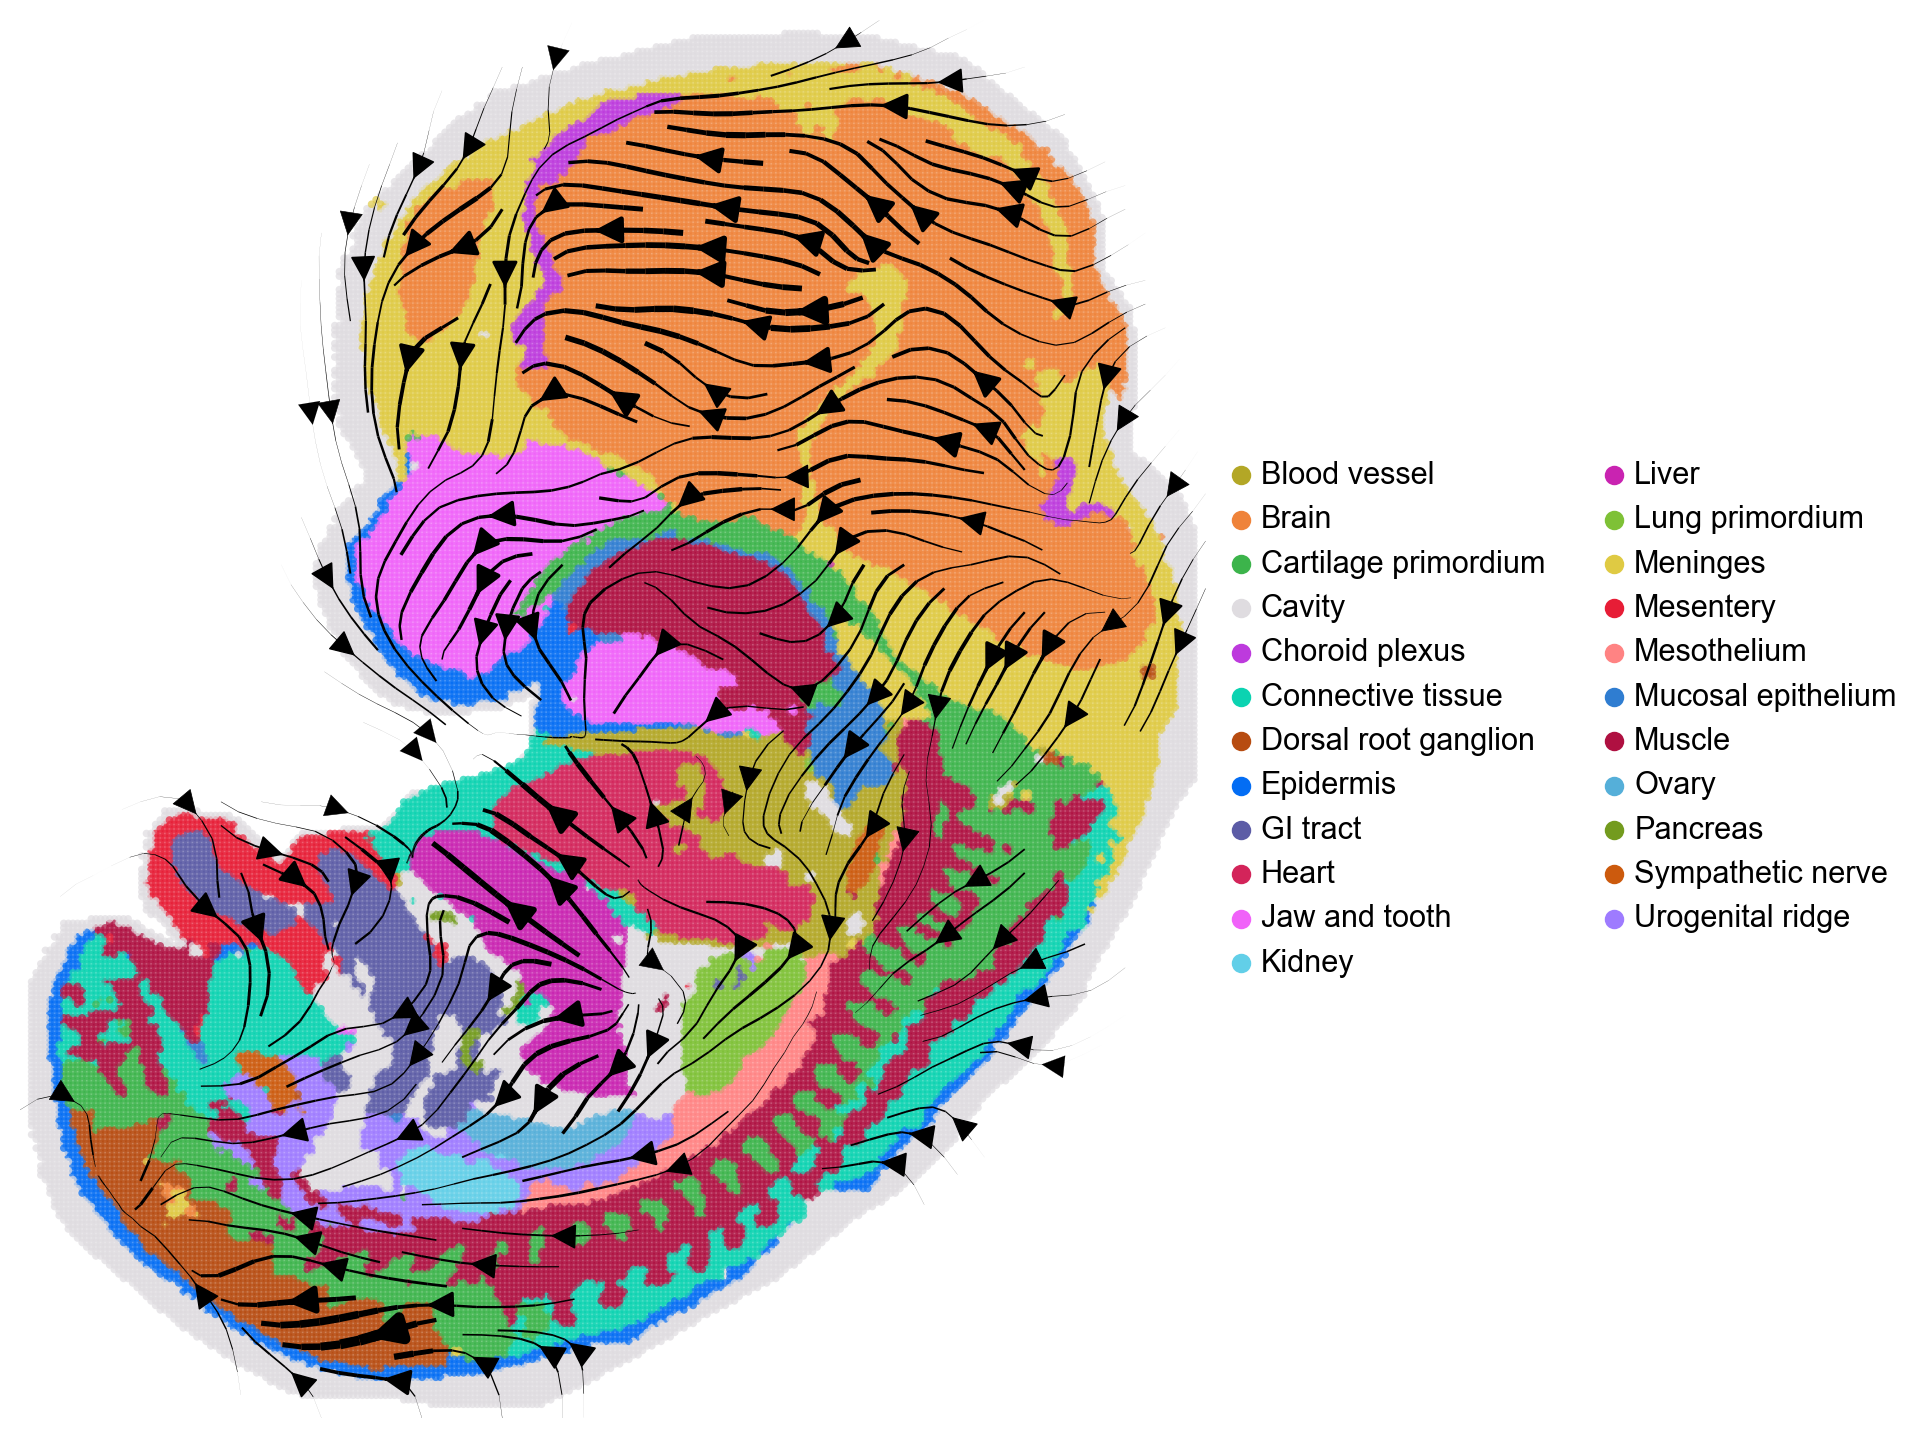

In [11]:
plt.rcParams["figure.figsize"] = (7.6, 9.2)
stv.velocity_embedding_stream(adata, basis='spatial', color="annotation", title="", legend_loc="right", alpha=0.7, size=30, 
                              linewidth=2, arrow_size=2)

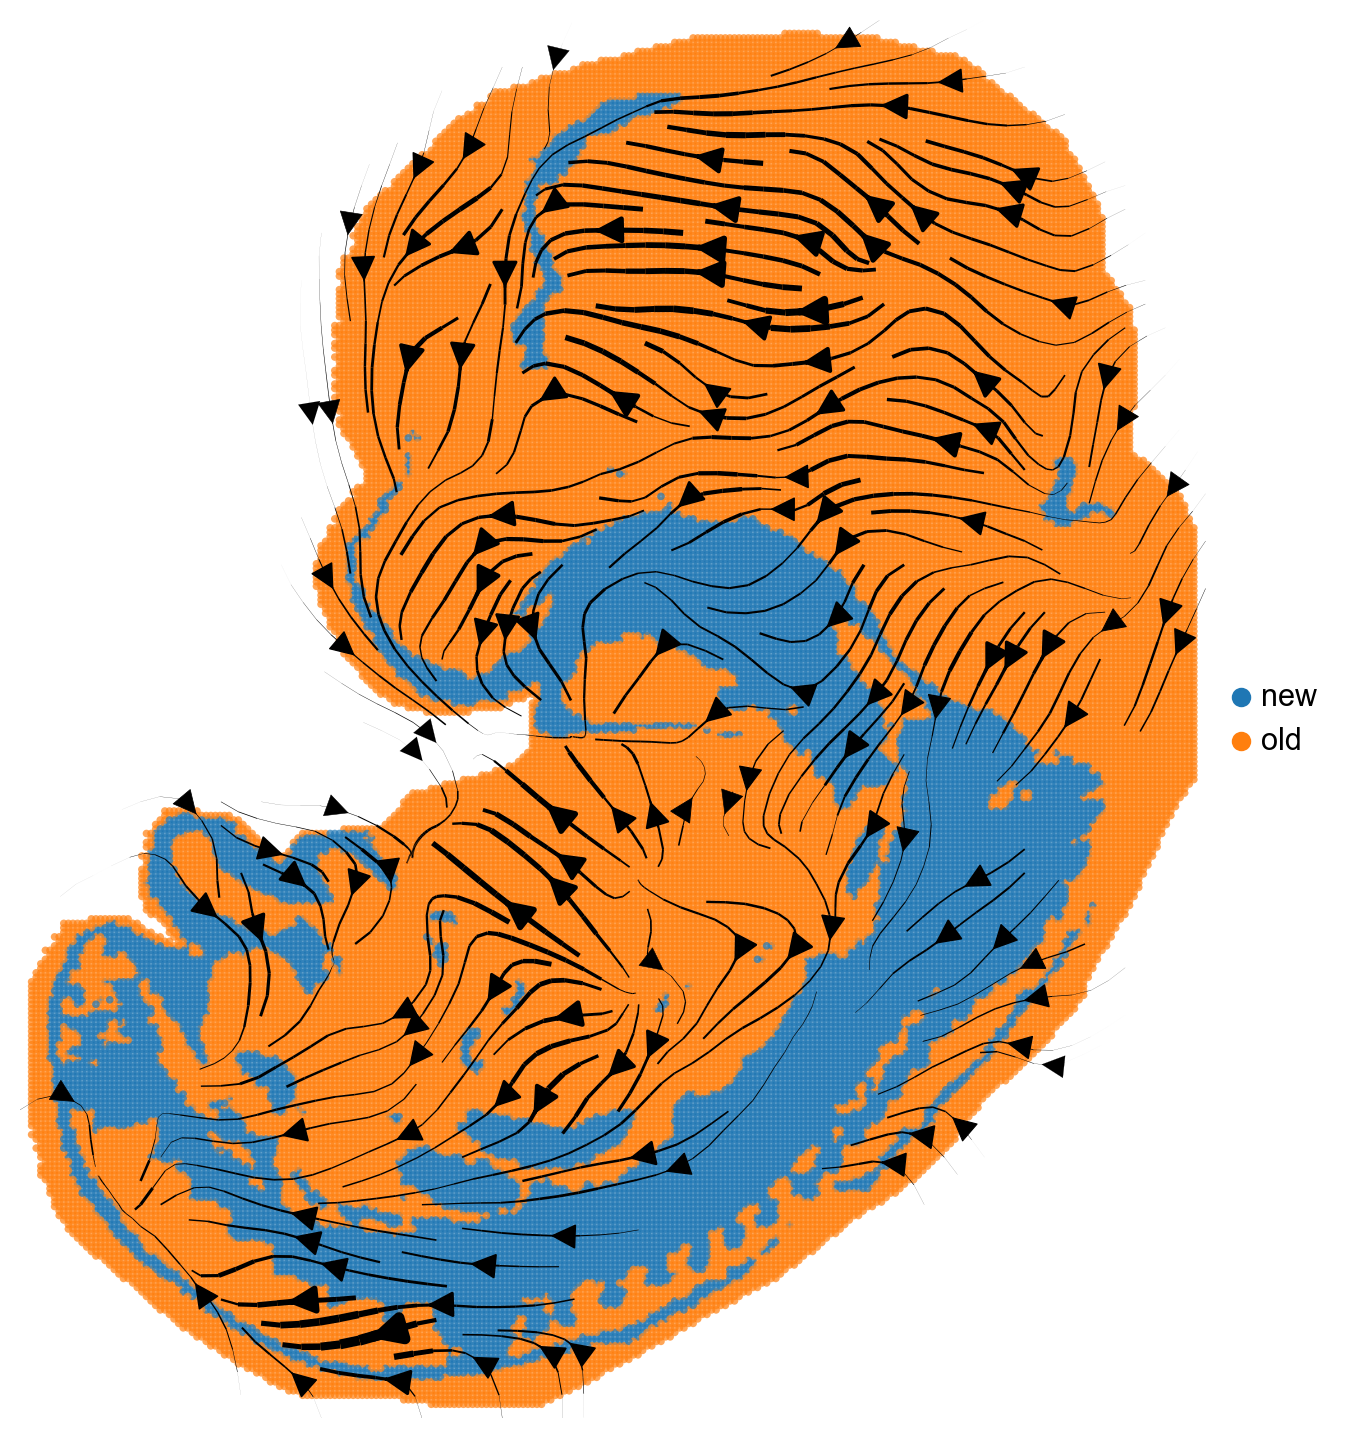

In [12]:
plt.rcParams["figure.figsize"] = (7.6, 9.2)
stv.velocity_embedding_stream(adata, basis='spatial', color="development", title="", legend_loc="right", alpha=0.7, size=30, 
                              linewidth=2, arrow_size=2)

In [13]:
#if not os.path.exists("./result"):
#    os.makedirs("./result")
#adata.write("./result/adata.h5ad")

# UMAP

In [14]:
sc.pp.neighbors(adata, use_rep='rep_2')
sc.tl.umap(adata)

computing velocity embedding
    finished (0:00:11) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


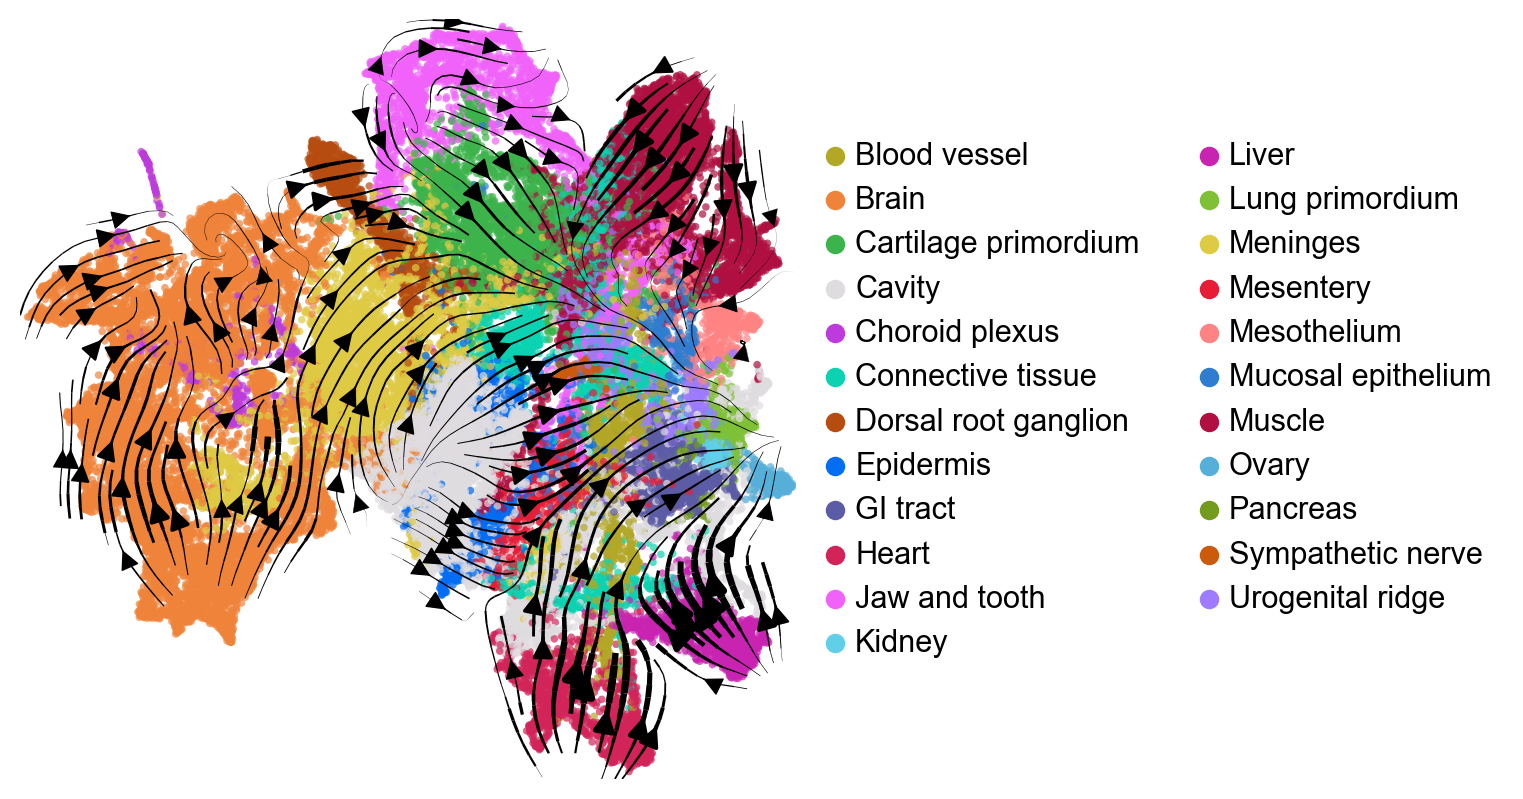

In [15]:
plt.rcParams["figure.figsize"] = (5, 5)
stv.velocity_embedding_stream(adata, basis='X_umap', color="annotation", title="", legend_loc="right", alpha=0.7, size=30,
                              linewidth=1.5, arrow_size=1.5)

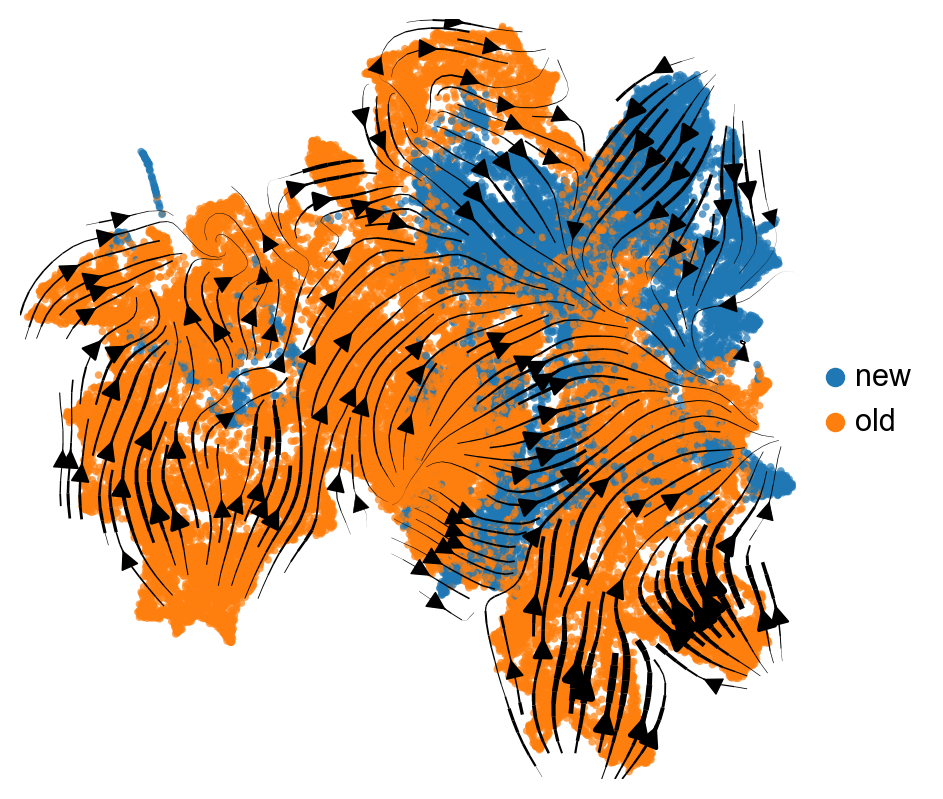

In [16]:
plt.rcParams["figure.figsize"] = (5, 5)
stv.velocity_embedding_stream(adata, basis='X_umap', color="development", title="", legend_loc="right", alpha=0.7, size=30, 
                              linewidth=1.5, arrow_size=1.5)